# Business Analytics Career Switch Project

This project demonstrates a typical workflow for a business or program analyst. It includes:

* **Synthetic dataset** simulating project management metrics (complexity, team size, budget, duration, stakeholders, risk) and outcomes (success flag and ROI).
* **Exploratory Data Analysis (EDA)** using tables, statistics and visualizations to understand the data.
* **Predictive modeling**:
  * Classification model to predict project success based on features
  * Regression model to predict return on investment (ROI)

The notebook is organised into sections of increasing difficulty: starting with simple summaries and plots, then building predictive models using scikit‑learn.

Feel free to experiment by modifying the code or extending the analysis to include other algorithms or evaluation metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, r2_score

# Display plots inline
%matplotlib inline


In [2]:
# Load the synthetic dataset
df = pd.read_csv('synthetic_project_data.csv')

# Display first five rows
df.head()

,project_id,complexity,team_size,budget_k,duration_weeks,stakeholder_count,risk_score,success,roi_percent
0,1,7,8,51,25,5,0.975067,1,73.381460
1,2,4,13,79,20,2,0.490749,1,65.082214
2,3,8,3,24,10,6,0.722896,1,70.544389
3,4,5,11,63,28,5,0.820861,1,72.184742
4,5,7,14,69,48,2,0.718457,0,56.592681


In [3]:
# Basic statistics
df.describe()

,project_id,complexity,team_size,budget_k,duration_weeks,stakeholder_count,risk_score,success,roi_percent
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,5.560000,8.515000,52.685000,27.260000,4.575000,0.516627,0.600000,64.038629
std,57.879185,2.899731,3.800261,26.496909,13.885114,2.282636,0.270104,0.491127,19.664880
min,1.000000,1.000000,3.000000,10.000000,4.000000,1.000000,0.002711,0.000000,10.110785
25%,50.750000,3.000000,5.000000,28.000000,16.000000,3.000000,0.298208,0.000000,50.415379
50%,100.500000,6.000000,8.000000,51.000000,28.000000,5.000000,0.533157,1.000000,64.394630
75%,150.250000,8.000000,12.000000,74.000000,38.250000,7.000000,0.747106,1.000000,78.312983
max,200.000000,10.000000,15.000000,100.000000,52.000000,8.000000,0.997693,1.000000,112.210259


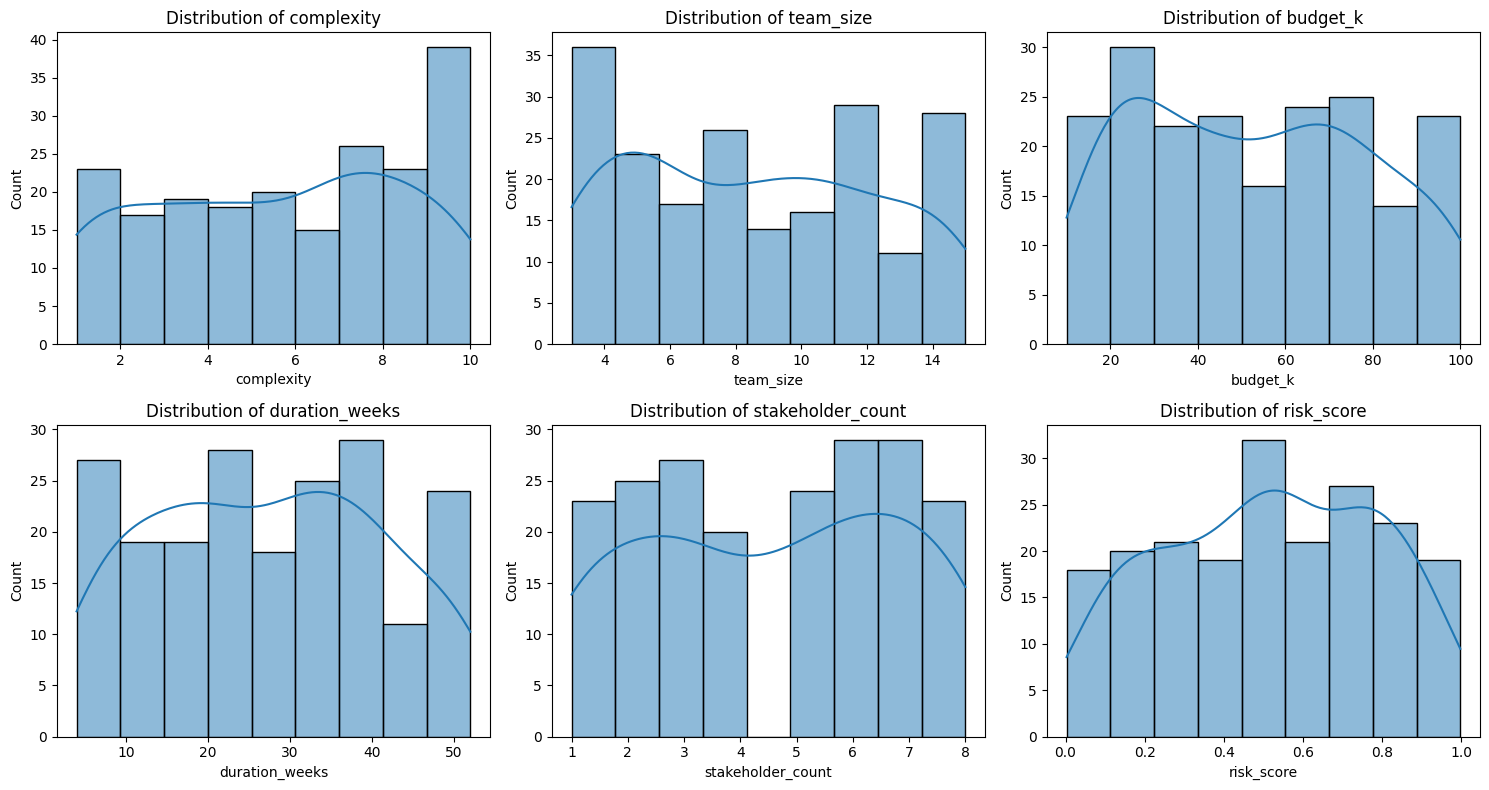

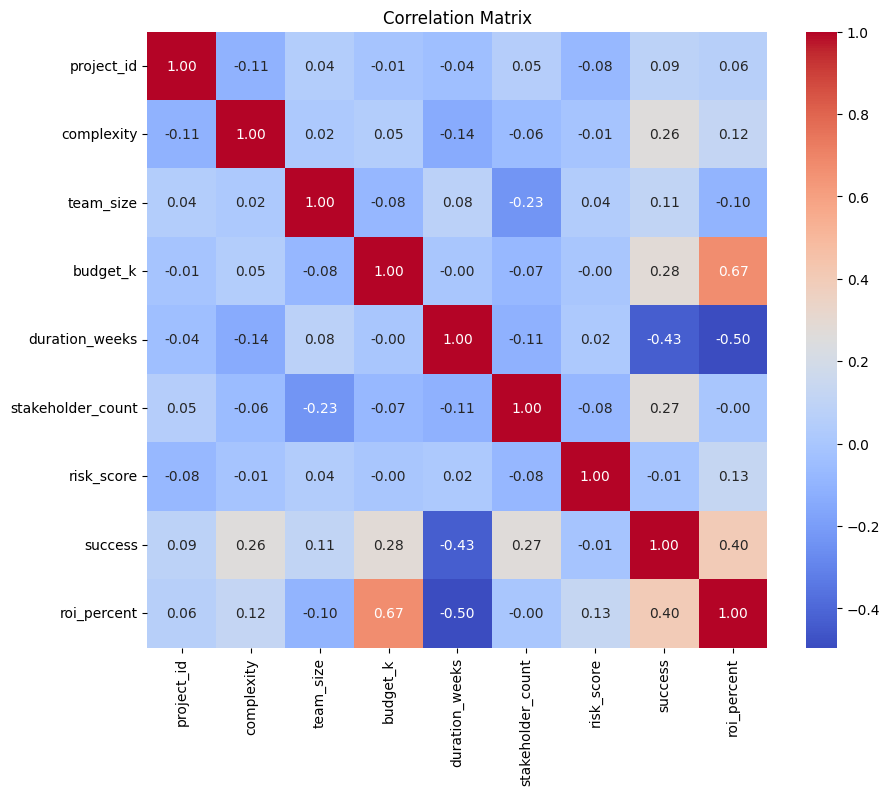

In [4]:
# Histograms for numerical features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols = ['complexity', 'team_size', 'budget_k', 'duration_weeks', 'stakeholder_count', 'risk_score']
for i, col in enumerate(cols):
    ax = axes[i//3, i%3]
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [5]:
# Classification: predict project success
X_class = df[['complexity', 'team_size', 'budget_k', 'duration_weeks', 'stakeholder_count', 'risk_score']]
y_class = df['success']

X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f'Classification Accuracy: {acc:.2f}')
print('Confusion Matrix:')
print(cm)

Classification Accuracy: 0.75
Confusion Matrix:
[[13  2]
 [ 8 17]]


In [6]:
# Regression: predict ROI
X_reg = df[['complexity', 'team_size', 'budget_k', 'duration_weeks', 'stakeholder_count', 'risk_score']]
y_reg = df['roi_percent']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

regr = RandomForestRegressor(n_estimators=200, random_state=42)
regr.fit(X_train_reg, y_train_reg)

y_pred_reg = regr.predict(X_test_reg)

mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f'Regression Mean Squared Error: {mse:.2f}')
print(f'Regression R^2 Score: {r2:.2f}')

Regression Mean Squared Error: 140.20
Regression R^2 Score: 0.68


## Conclusion

This notebook demonstrates a straightforward workflow for a business analyst or program manager:

1. **Data generation & loading**: We used a synthetic dataset representative of project management metrics.
2. **Exploratory analysis**: Histograms and a correlation matrix help understand feature distributions and relationships.
3. **Classification**: A logistic regression model predicted project success with a certain level of accuracy. You can try other algorithms (e.g., decision trees or random forests) for potentially improved performance.
4. **Regression**: A random forest regressor predicted ROI; the mean squared error and $R^2$ score provide insight into model fit.

### Next Steps

To expand the project:

* Add more features (e.g., project methodology, industry, location).
* Try feature engineering and scaling for improved model performance.
* Compare multiple classification and regression algorithms.
* Use cross‑validation and hyperparameter tuning.

This repository is ready to use. Simply run the notebook to reproduce the analysis and experiment with your own ideas!
